Libraries imported successfully.
Dataset loaded successfully.
Dataset shape: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Client_ID                1000 non-null   object 
 1   Industry                 1000 non-null   object 
 2   Contract_Length          1000 non-null   int64  
 3   Renewal_Status           1000 non-null   object 
 4   Monthly_Marketing_Spend  1000 non-null   float64
 5   Campaign_Count           1000 non-null   int64  
 6   Leads                    1000 non-null   int64  
 7   Conversions              1000 non-null   int64  
 8   Conversion_Rate          1000 non-null   float64
 9   Website_Visits           1000 non-null   int64  
 10  Social_Engagement        1000 non-null   int64  
 11  Campaign_Performance     1000 non-null   float64
 12  Ad_Spend                 1000 non-null   floa

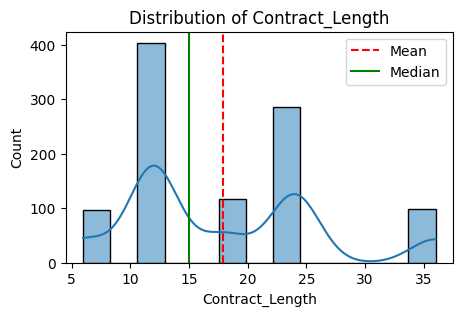

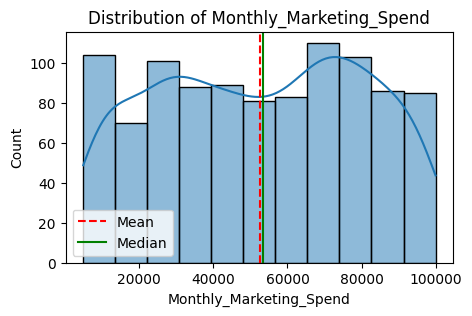

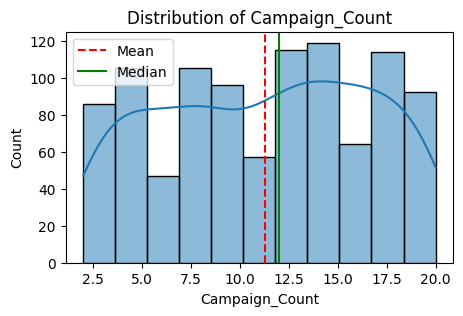

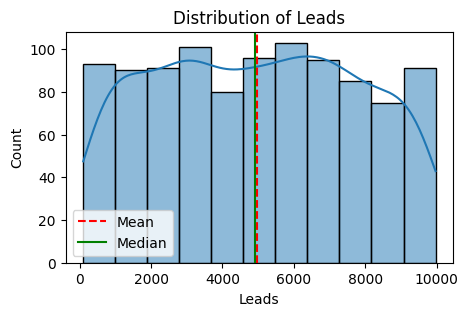

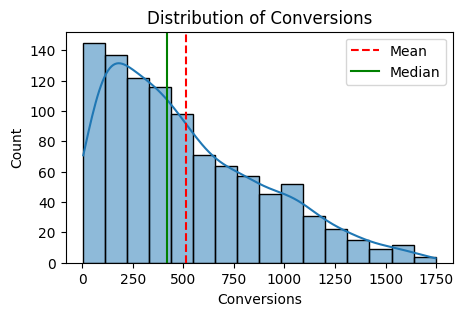

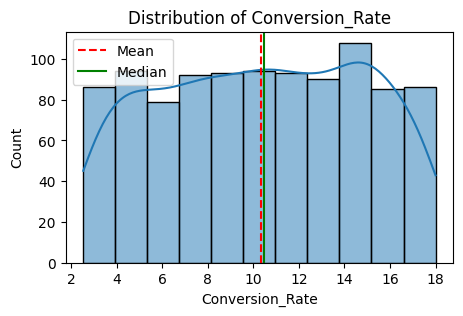

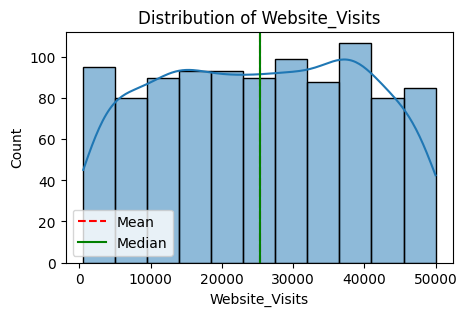

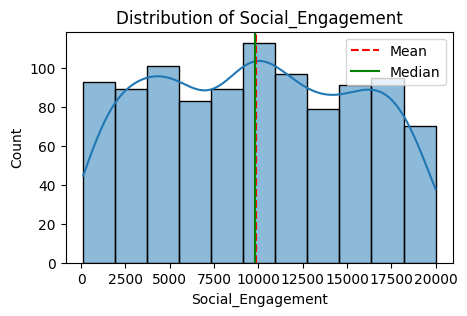

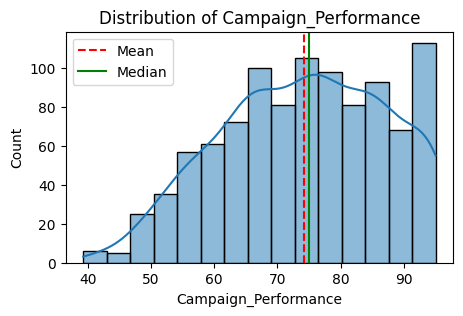

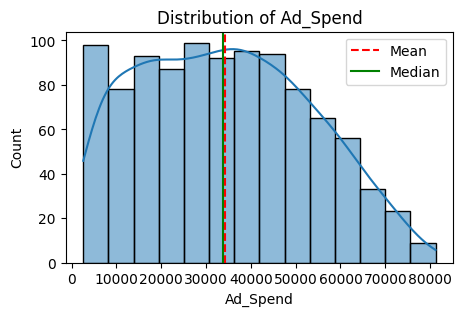

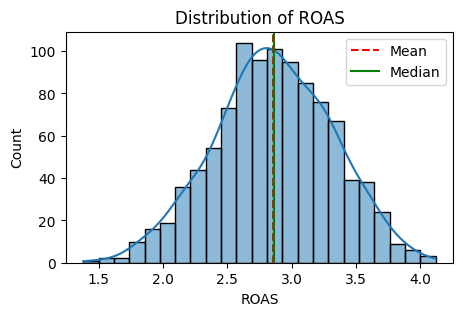

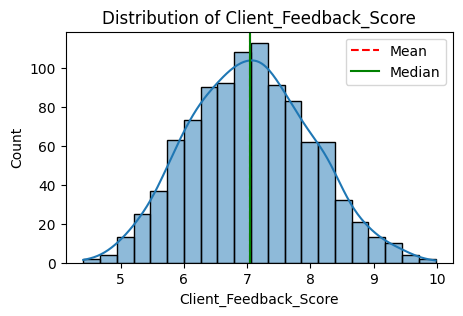

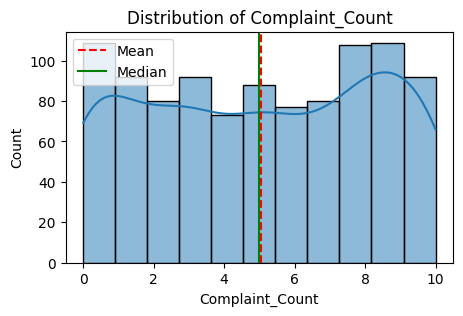

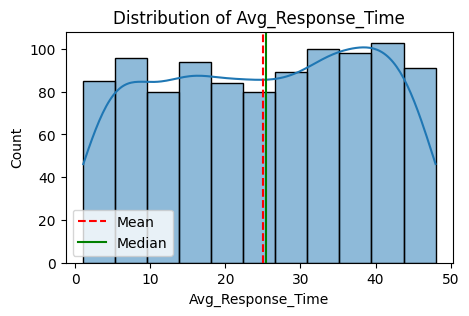

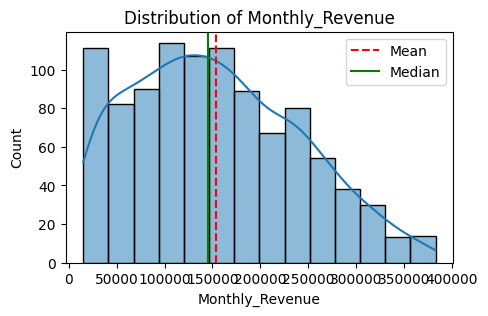

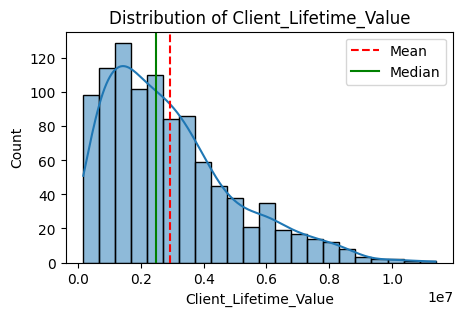

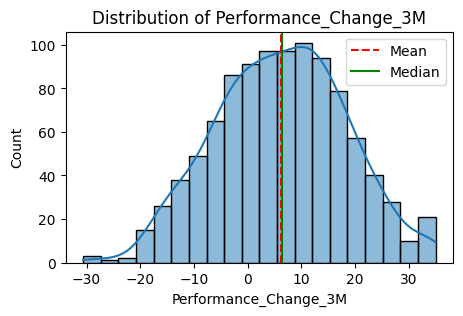

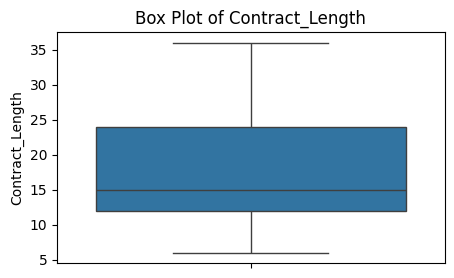

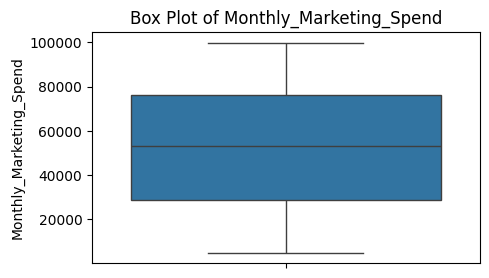

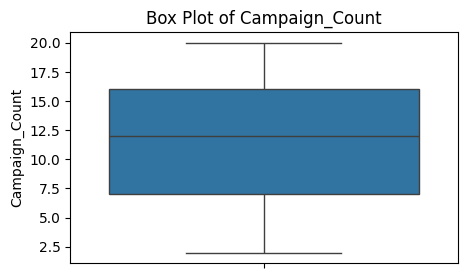

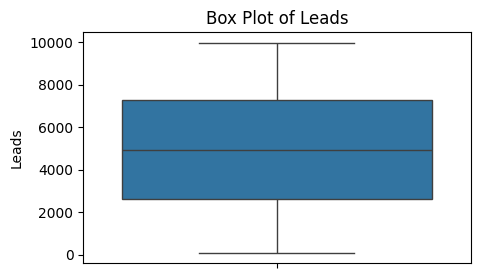

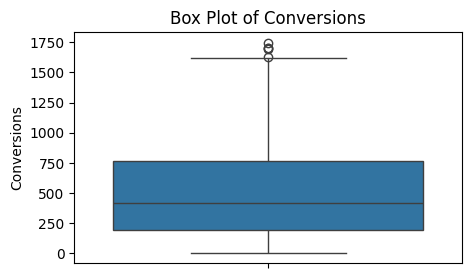

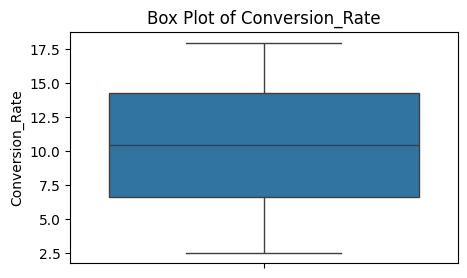

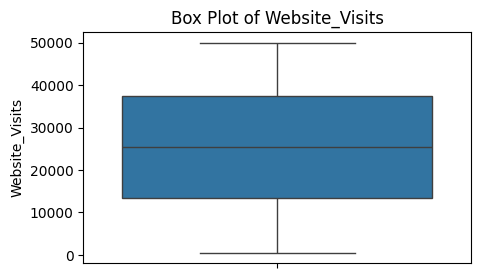

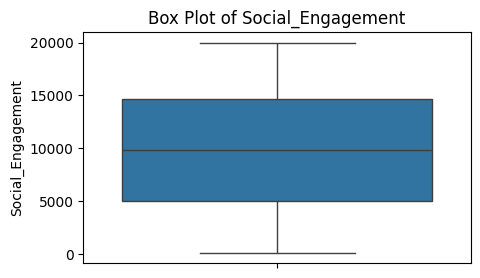

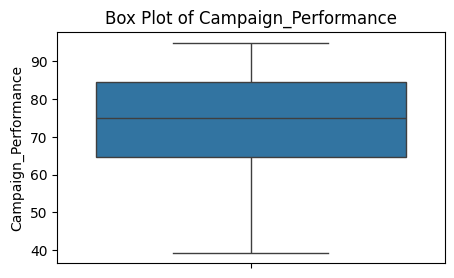

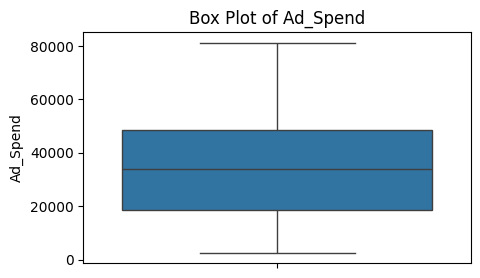

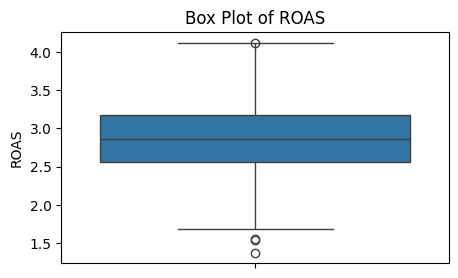

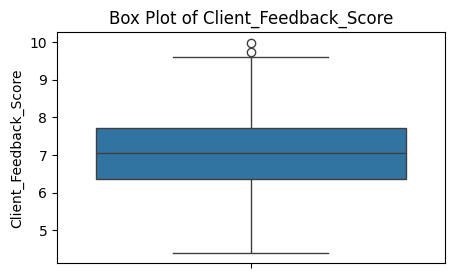

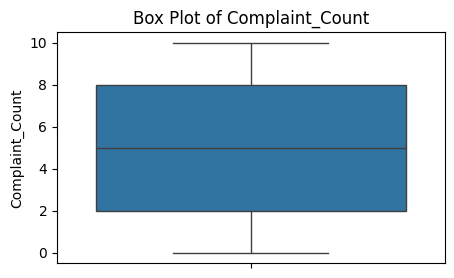

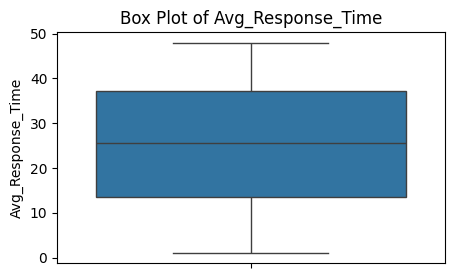

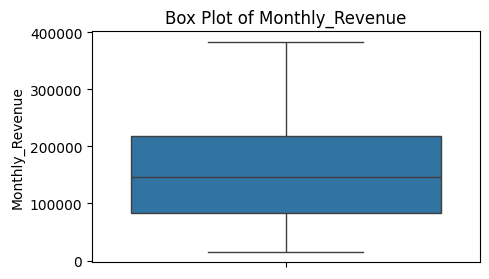

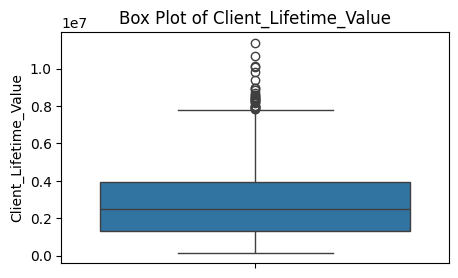

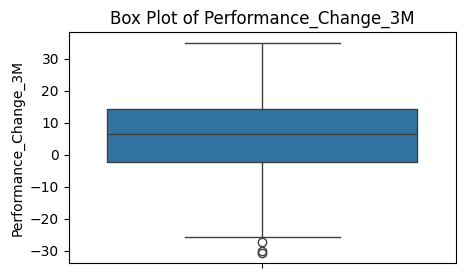

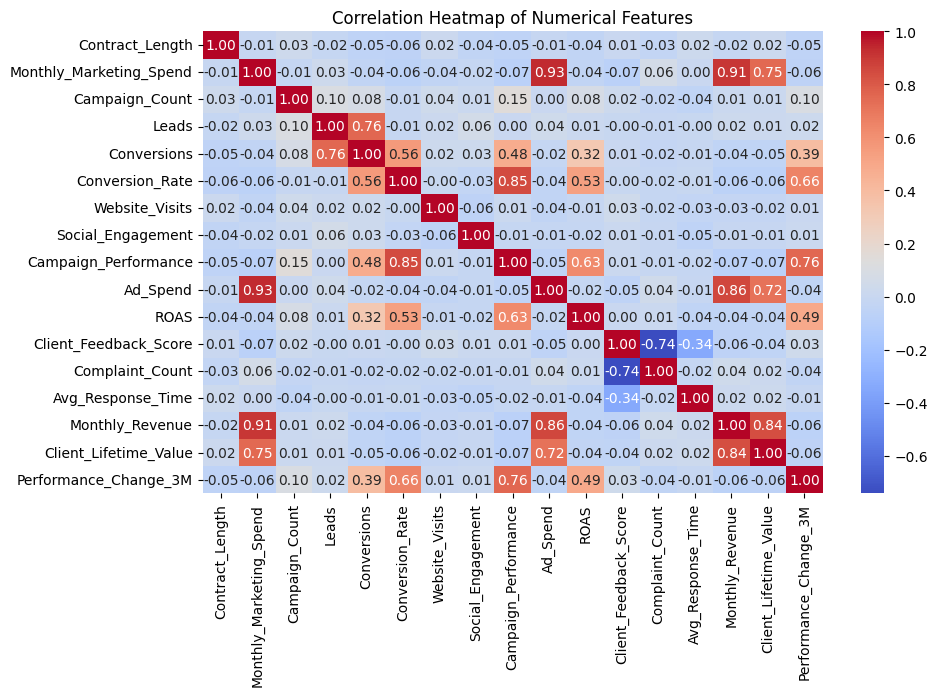


Unique values in 'Industry': ['Travel' 'Education' 'Technology' 'Finance' 'Retail' 'Healthcare'
 'Real Estate' 'E-commerce']

Unique values in 'Renewal_Status': ['Renewed' 'Pending' 'Not Renewed']

Categorical columns: ['Industry', 'Renewal_Status']


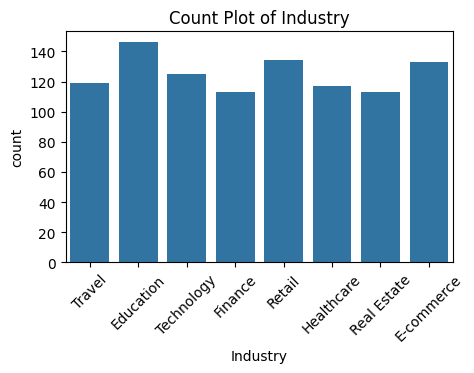

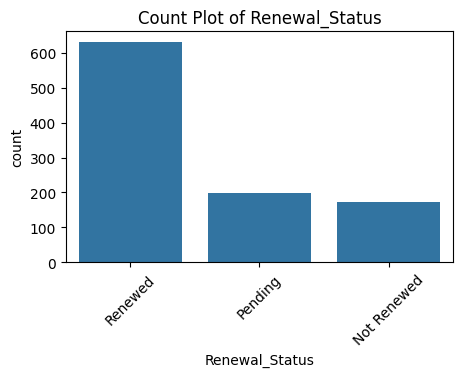

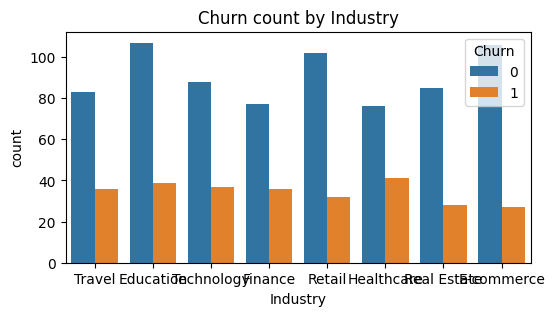

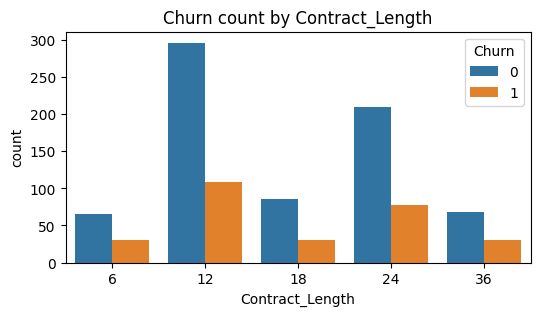

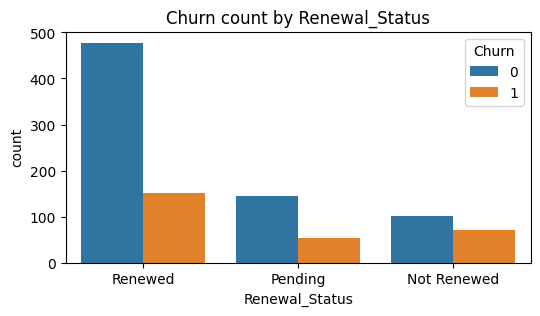

Object columns to encode: Index(['Industry', 'Renewal_Status'], dtype='object')
Categorical features have been label encoded.
Encoders saved to 'encoders.pkl'.
Churn value counts:
Churn
0    724
1    276
Name: count, dtype: int64

Churn data type: int64
Feature set shape: (1000, 19)
Target set shape: (1000,)
Training data shape: (800, 19)
Test data shape: (200, 19)
Training target distribution:
Churn
0    579
1    221
Name: count, dtype: int64
Test target distribution:
Churn
0    145
1     55
Name: count, dtype: int64
After SMOTE:
X_train_smote shape: (1158, 19)
y_train_smote shape: (1158,)
y_train_smote value counts:
Churn
0    579
1    579
Name: count, dtype: int64
Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.7039 (+/- 0.0597)
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.7963 (+/- 0.0555)
-------------------------------------

In [3]:
# %% [markdown]
# # Customer Churn Prediction
#
# This notebook follows the same workflow as the provided example but uses the `client_churn_marketing_dataset_1000.csv` file.
#
# **Workflow:**
# 1. Importing Dependencies
# 2. Data Loading and Understanding
# 3. Exploratory Data Analysis (EDA)
# 4. Data Preprocessing (Encoding, SMOTE)
# 5. Model Training (using Random Forest as the best performer)
# 6. Model Evaluation
# 7. Saving the Model and Building a Predictive System

# %% [markdown]
# **1. Importing the dependencies**

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

# %% [markdown]
# **2. Data Loading and Understanding**

# %%
# Load the CSV data to a pandas dataframe
# In Colab, upload the file or mount Google Drive.
# For now, assume the file is in the current directory.
df = pd.read_csv("client_churn_marketing_dataset_1000.csv")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

# %%
# Display the first few rows
df.head()

# %%
# Get a concise summary of the DataFrame
df.info()

# %%
# Check for missing values in the dataset
print(df.isnull().sum())

# %%
# Let's look at the 'Churn' column distribution
# In this dataset, 'Churn' is already numeric (0/1)
print(df["Churn"].value_counts())

# %%
# Check data types and unique values for categorical columns
object_columns = df.select_dtypes(include="object").columns
print("Object type columns:", object_columns)

for col in object_columns:
    print(f"\nUnique values in '{col}': {df[col].unique()}")

# 'Client_ID' is an identifier and not useful for modelling. We'll drop it.
df = df.drop(columns=["Client_ID"], errors='ignore')
print("\n'Client_ID' column dropped.")

# %% [markdown]
# **Insights:**
# 1. The dataset has 1000 rows and 21 columns.
# 2. There are no missing values.
# 3. The target column 'Churn' is already encoded as 0/1.
# 4. There is a class imbalance in the target variable. We will address this using SMOTE.
# 5. The 'Client_ID' column was dropped as it's not required for modeling.

# %% [markdown]
# **3. Exploratory Data Analysis (EDA)**

# %% [markdown]
# **Numerical Features - Analysis**

# %%
# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Churn') # remove the target variable
print("Numerical columns:", numerical_cols)

# %%
# Understand the distribution of the numerical features
def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")

    # calculate the mean and median values for the columns
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()

    # add vertical lines for mean and median
    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="-", label="Median")
    plt.legend()
    plt.show()

for col in numerical_cols:
    plot_histogram(df, col)

# %%
# Box plot for numerical features
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

for col in numerical_cols:
    plot_boxplot(df, col)

# %%
# Correlation Heatmap for numerical columns
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# %% [markdown]
# **Categorical Features - Analysis**

# %%
# Get unique values for categorical columns
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\nUnique values in '{col}': {df[col].unique()}")

# We can also include 'Renewal_Status' and 'Industry' as categorical features
categorical_cols = categorical_cols.tolist()
print("\nCategorical columns:", categorical_cols)

# %%
# Countplot for categorical columns
for col in categorical_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

# %%
# Let's see the relationship between 'Churn' and some key features
for col in ['Industry', 'Contract_Length', 'Renewal_Status']:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=df[col], hue=df['Churn'])
    plt.title(f'Churn count by {col}')
    plt.show()

# %% [markdown]
# **Key Observations from EDA:**
# - We have a mix of numerical (e.g., `tenure`, `MonthlyCharges`) and categorical (e.g., `Industry`, `Contract_Length`) features.
# - Features like `Contract_Length` and `Renewal_Status` seem to have a significant impact on churn.
# - The target variable is imbalanced, which we will handle.

# %% [markdown]
# **4. Data Preprocessing**

# %%
# Label encoding of categorical features
# Identify all columns that are of type 'object'
object_columns = df.select_dtypes(include="object").columns
print("Object columns to encode:", object_columns)

# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

print("Categorical features have been label encoded.")

# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)
print("Encoders saved to 'encoders.pkl'.")

# %%
df.head()

# %%
# Verify target column is numeric and check its distribution
print("Churn value counts:")
print(df["Churn"].value_counts())
print("\nChurn data type:", df["Churn"].dtype)

# %% [markdown]
# **Training and Test Data Split**

# %%
# splitting the features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature set shape:", X.shape)
print("Target set shape:", y.shape)

# %%
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")

# %% [markdown]
# **Synthetic Minority Oversampling Technique (SMOTE)**

# %%
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:")
print(f"X_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print(f"y_train_smote value counts:\n{y_train_smote.value_counts()}")

# %% [markdown]
# **5. Model Training**

# %% [markdown]
# Training with default hyperparameters

# %%
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross-validation accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")
    print("-"*70)

# %%
cv_scores

# %% [markdown]
# Random Forest gives the highest accuracy compared to other models with default parameters.

# %%
# Train the best model (Random Forest) on the full SMOTE training data
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
rfc.fit(X_train_smote, y_train_smote)

print("Random Forest model trained on SMOTE data.")

# %% [markdown]
# **6. Model Evaluation**

# %%
# Evaluate on test data
y_test_pred = rfc.predict(X_test)

print("--- Model Performance on Test Data ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# %%
# Save the trained model and feature names
model_data = {"model": rfc, "features_names": X.columns.tolist()}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved to 'customer_churn_model.pkl'.")

# %% [markdown]
# **7. Load the Saved Model and Build a Predictive System**

# %%
# Load the saved model and the encoders
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

print("Model and feature names loaded.")

# %%
print("Expected features:", feature_names)

# %%
# Example: Making a prediction on a new customer
# Let's use the first row of our original test set as an example
sample_data = X_test.iloc[0:1].copy()
original_data = pd.read_csv("client_churn_marketing_dataset_1000.csv").iloc[0]
print("Example Customer Data (from test set):")
# To show original data values, we need to decode them. This is just for display.
print("Original data before encoding:", original_data.to_dict())

# The 'sample_data' is already encoded, so we can directly predict
prediction = loaded_model.predict(sample_data)
pred_prob = loaded_model.predict_proba(sample_data)

print("\n--- Prediction Result ---")
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediction Probability (No Churn, Churn): {pred_prob[0]}")

# %% [markdown]
# **Conclusion:**
#
# The Random Forest model, trained on SMOTE-balanced data, provides a reasonable accuracy for predicting customer churn. The model, encoders, and feature names have been saved for deployment in a predictive system.


In [2]:
from google.colab import files

# This will open a file upload dialog. Please select 'client_churn_marketing_dataset_1000.csv'
uploaded = files.upload()

Saving client_churn_marketing_dataset_1000.csv to client_churn_marketing_dataset_1000.csv
